<a href="https://colab.research.google.com/github/AbhishekShah272002/Deep-Learning-and-NLP/blob/main/Transformer_Based_Household_Power_Consumption_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout, # Randomly drops some neuron outputs during training to help reduce overfitting.
    LayerNormalization, # Normalizes intermediate values inside the Transformer and helps make training more stable.
    MultiHeadAttention,  # This is the main Transformer component.It allows the model to examine the 60 previous time steps and learn relationships among them.
    GlobalAveragePooling1D # convert the sequence representation into a fixed-size representation before final prediction.
)

from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";"
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape: (652248, 9)

Column Names:
Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

Data Types:
Date                      object
Time                      object
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652248 entries, 0 to 652247
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Date                   652248 non-null  object 
 1   Time                   652248 non-null  object 
 2   Global_active_power    652247 non-null  object 
 3   Global_reactive_power  652247 non-null 

In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nNumber of '?' values:")
print((df == '?').sum())

Missing Values:
Date                        0
Time                        0
Global_active_power         1
Global_reactive_power       1
Voltage                     1
Global_intensity            1
Sub_metering_1              1
Sub_metering_2              1
Sub_metering_3           3940
dtype: int64

Number of '?' values:
Date                        0
Time                        0
Global_active_power      3939
Global_reactive_power    3939
Voltage                  3939
Global_intensity         3939
Sub_metering_1           3939
Sub_metering_2           3939
Sub_metering_3              0
dtype: int64


In [5]:
df.replace('?', np.nan, inplace=True)

df.dropna(inplace=True)

print("Missing Values After Cleaning:")
print(df.isnull().sum())

print("\nUpdated Dataset Shape:", df.shape)

Missing Values After Cleaning:
Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

Updated Dataset Shape: (648308, 9)


In [6]:
df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0,2006-12-16 17:28:00


In [7]:
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power']
)

print(df['Global_active_power'].dtype)
print(df['Global_active_power'].head())

float64
0    4.216
1    5.360
2    5.374
3    5.388
4    3.666
Name: Global_active_power, dtype: float64


In [8]:
data = df[['Global_active_power']].values

print("First 5 Values:")
print(data[:5])

print("\nData Shape:", data.shape)

First 5 Values:
[[4.216]
 [5.36 ]
 [5.374]
 [5.388]
 [3.666]]

Data Shape: (648308, 1)


In [9]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(data)

print("First 5 Original Values:")
print(data[:5])

print("\nFirst 5 Scaled Values:")
print(scaled_data[:5])

First 5 Original Values:
[[4.216]
 [5.36 ]
 [5.374]
 [5.388]
 [3.666]]

First 5 Scaled Values:
[[0.39044201]
 [0.49848886]
 [0.49981111]
 [0.50113336]
 [0.33849641]]


In [10]:
X = []
y = []

time_step = 60

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nFirst Input Sequence:")
print(X[0])

print("\nFirst Target:")
print(y[0])

X Shape: (648248, 60)
y Shape: (648248,)

First Input Sequence:
[0.39044201 0.49848886 0.49981111 0.50113336 0.33849641 0.32470722
 0.34189649 0.34170759 0.3386853  0.33811862 0.41235361 0.50340008
 0.48564413 0.48979977 0.37514167 0.31186249 0.30109558 0.31620703
 0.30071779 0.3443521  0.54892331 0.72006045 0.6558368  0.4809218
 0.41480922 0.29901776 0.2978844  0.29712883 0.29996222 0.2924065
 0.24914998 0.34718549 0.40234227 0.41839819 0.37551946 0.22572724
 0.25576124 0.24008311 0.2540612  0.34548546 0.45768795 0.56384586
 0.62995844 0.6037023  0.58802418 0.41386475 0.31299584 0.2840952
 0.34454099 0.21023801 0.21779373 0.42652059 0.41953155 0.38911976
 0.41462032 0.26161692 0.26879486 0.26992822 0.26936154 0.26860597]

First Target:
0.31828485077446167


In [11]:
print("Last Sequence Number:", len(X))
print("Last Sequence Index:", len(X) - 1)
print("Last Sequence:", X[-1])
print("Last Target:", y[-1])

Last Sequence Number: 648248
Last Sequence Index: 648247
Last Sequence: [0.04023423 0.03947866 0.03947866 0.03910087 0.03872308 0.03777862
 0.03740083 0.03702304 0.03721194 0.03758972 0.03740083 0.03418965
 0.03022289 0.03022289 0.02890064 0.02058935 0.02058935 0.02058935
 0.02115603 0.02115603 0.02096713 0.02096713 0.02115603 0.02040045
 0.02040045 0.02040045 0.02077824 0.02077824 0.02077824 0.02096713
 0.02002267 0.02002267 0.02021156 0.02040045 0.02040045 0.02058935
 0.02058935 0.02002267 0.02002267 0.02002267 0.02002267 0.02058935
 0.02077824 0.02077824 0.02342274 0.02757839 0.02776728 0.02776728
 0.02757839 0.0273895  0.0272006  0.03588969 0.03626747 0.03777862
 0.05685682 0.06309029 0.03966755 0.03966755 0.03947866 0.03758972]
Last Target: 0.196448809973555


In [13]:
train_size = int(len(X) * 0.80)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (518598, 60)
X_test : (129650, 60)
y_train: (518598,)
y_test : (129650,)


In [14]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (518598, 60, 1)
X_test Shape: (129650, 60, 1)


In [15]:
inputs = Input(shape=(60, 1))
# Defines the input: 60 previous minutes and 1 feature (Global_active_power)

x = MultiHeadAttention(
    num_heads=2,
    # Uses two parallel attention heads to learn different relationships
    # among the 60 time steps

    key_dim=4
    # Each attention head uses a 4-dimensional internal representation
    # while calculating attention
)(inputs, inputs)
# The same input is used for both arguments, so it performs self-attention

x = LayerNormalization()(x)
# Normalizes the attention output to make training more stable

x = Dense(32, activation='relu')(x)
# Uses 32 neurons with ReLU activation to learn additional nonlinear patterns
# from the attention output

x = GlobalAveragePooling1D()(x)
# Combines/summarizes information from all 60 time steps into one representation

outputs = Dense(1)(x)
# Final output layer with one neuron to predict the next-minute
# Global_active_power value

model_transformer = Model(inputs, outputs)
# Connects the input and output layers to create the complete Transformer model

model_transformer.summary()
# Displays the model architecture, output shapes, and number of parameters

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 1)     │         57 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 1)     │          2 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 60, 32)    │         64 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ dense[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 156 (624.00 B)

 Trainable params: 156 (624.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
model_transformer.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error', # Mean Squared Error (MSE) as the loss function.
    metrics=['mae'] # MAE tells us the average absolute difference between actual and predicted values.
)

In [17]:
history_transformer = model_transformer.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.20,
    shuffle=False,
    verbose=1
)

Epoch 1/5
12965/12965 ━━━━━━━━━━━━━━━━━━━━ 121s 9ms/step - loss: 0.0110 - mae: 0.0783 - val_loss: 0.0131 - val_mae: 0.0874
Epoch 2/5
12965/12965 ━━━━━━━━━━━━━━━━━━━━ 141s 9ms/step - loss: 0.0108 - mae: 0.0780 - val_loss: 0.0131 - val_mae: 0.0874
Epoch 3/5
12965/12965 ━━━━━━━━━━━━━━━━━━━━ 117s 9ms/step - loss: 0.0108 - mae: 0.0780 - val_loss: 0.0131 - val_mae: 0.0874
Epoch 4/5
12965/12965 ━━━━━━━━━━━━━━━━━━━━ 142s 9ms/step - loss: 0.0108 - mae: 0.0780 - val_loss: 0.0131 - val_mae: 0.0874
Epoch 5/5
12965/12965 ━━━━━━━━━━━━━━━━━━━━ 126s 10ms/step - loss: 0.0108 - mae: 0.0780 - val_loss: 0.0131 - val_mae: 0.0874


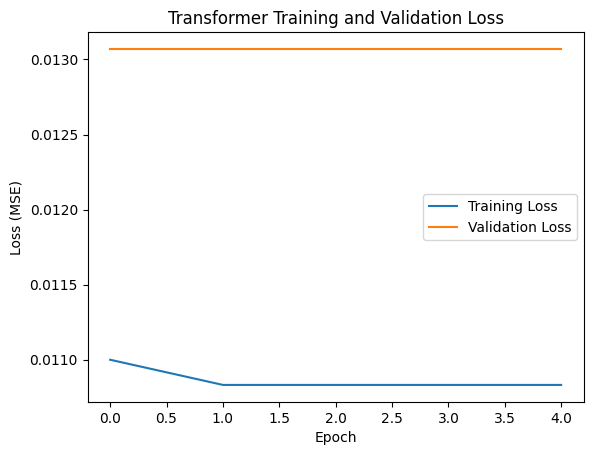

In [18]:
plt.plot(history_transformer.history['loss'], label='Training Loss')
plt.plot(history_transformer.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Transformer Training and Validation Loss')
plt.legend()
plt.show()